<a href="https://colab.research.google.com/github/mishal-2408/AI23531-DEEP-LEARNING/blob/main/exp_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 170M/170M [14:11<00:00, 200kB/s]


Device: cpu
Starting training...

Epoch [1/10], Loss: 1.4347
Epoch [2/10], Loss: 1.0903
Epoch [3/10], Loss: 0.9469
Epoch [4/10], Loss: 0.8390
Epoch [5/10], Loss: 0.7600
Epoch [6/10], Loss: 0.6894
Epoch [7/10], Loss: 0.6189
Epoch [8/10], Loss: 0.5559
Epoch [9/10], Loss: 0.4983
Epoch [10/10], Loss: 0.4436

Training completed!

Accuracy on test data: 70.20%


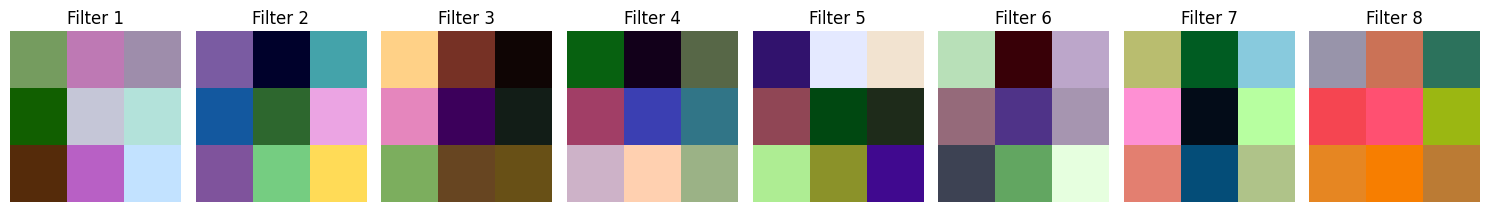

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


# ==========================================
# STEP 1: LOAD AND PREPROCESS CIFAR-10
# ==========================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

classes = trainset.classes


# ==========================================
# STEP 2: DEFINE CNN
# ==========================================

class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            3, 16, 3, padding=1
        )

        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(
            16, 32, 3, padding=1
        )

        self.fc1 = nn.Linear(
            32 * 8 * 8,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

        self.relu = nn.ReLU()


    def forward(self, x):

        x = self.pool(
            self.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            self.relu(
                self.conv2(x)
            )
        )

        x = x.view(
            -1,
            32 * 8 * 8
        )

        x = self.relu(
            self.fc1(x)
        )

        x = self.fc2(x)

        return x


# ==========================================
# STEP 3: TRAIN CNN
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = SimpleCNN().to(device)

lossfn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 10

print("Device:", device)
print("Starting training...\n")


for epoch in range(num_epochs):

    running_loss = 0.0

    model.train()

    for inputs, labels in trainloader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = lossfn(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(trainloader)
    )

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )


print("\nTraining completed!")


# ==========================================
# STEP 4: EVALUATE MODEL
# ==========================================

correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


accuracy = 100 * correct / total

print(
    f"\nAccuracy on test data: "
    f"{accuracy:.2f}%"
)


# ==========================================
# STEP 5: VISUALIZE LEARNED FILTERS
# ==========================================

def visualize_filters(
    layer,
    n_filters=8
):

    filters = (
        layer.weight.data
        .clone()
        .cpu()
    )

    fig, axes = plt.subplots(
        1,
        n_filters,
        figsize=(15, 4)
    )

    for i in range(n_filters):

        f = filters[i]

        f = (
            f - f.min()
        ) / (
            f.max() - f.min()
        )

        f = f.permute(
            1, 2, 0
        )

        axes[i].imshow(f)

        axes[i].axis('off')

        axes[i].set_title(
            f'Filter {i + 1}'
        )

    plt.tight_layout()

    plt.show()


visualize_filters(
    model.conv1,
    n_filters=8
)